# SimCLR Embedding Evaluation

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Upload data


In [7]:
import kagglehub
import numpy as np
kagglehub.dataset_download('tonygordonjr/spotify-dataset-2023')

path = r'/kaggle/input/spotify-dataset-2023/spotify_data_12_20_2023.csv'
songs = pd.read_csv(path, low_memory=False)

numeric_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence', 'tempo', 'loudness', 'duration_ms'
]
categorical_features = ['genre_0', 'genre_1', 'genre_2', 'genre_3']

df = songs[numeric_features + categorical_features].copy()

df = df[df['genre_0'].notna()].reset_index(drop=True)
print(f"Tracks: {len(df):,}")

for f in numeric_features:
    df[f] = df[f].fillna(df[f].median())
    df[f] = df[f].clip(df[f].quantile(0.01), df[f].quantile(0.99))

for f in ['duration_ms', 'speechiness', 'liveness', 'instrumentalness']:
    df[f] = np.log1p(df[f])
df['loudness'] = np.log1p(df['loudness'] - df['loudness'].min())

scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_features]).astype('float32')

genre_encoders = {}
X_genres = np.zeros((len(df), len(categorical_features)), dtype=np.int64)
for i, col in enumerate(categorical_features):
    le = LabelEncoder()
    values = df[col].fillna('unknown').values
    encoded = le.fit_transform(values) + 1
    X_genres[:, i] = encoded
    genre_encoders[col] = le

genre_vocab_size = X_genres.max() + 1
input_num_dim = X_num.shape[1]
print(f"input_num_dim={input_num_dim}, genre_vocab_size={genre_vocab_size}")

Using Colab cache for faster access to the 'spotify-dataset-2023' dataset.
Tracks: 209,863
input_num_dim=10, genre_vocab_size=3009


## 2. Upload model




In [8]:
class Encoder(nn.Module):
    def __init__(self, num_dim, genre_vocab_size, genre_embed_dim=32, latent_dim=128):
        super().__init__()
        self.genre_embedding = nn.Embedding(
            genre_vocab_size, genre_embed_dim, padding_idx=0
        )
        genre_flat_dim = genre_embed_dim * 4
        self.net = nn.Sequential(
            nn.Linear(num_dim + genre_flat_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x_num, x_genres):
        g_emb = self.genre_embedding(x_genres)
        g_emb = g_emb.view(g_emb.size(0), -1)
        x = torch.cat([x_num, g_emb], dim=1)
        return F.normalize(self.net(x), dim=1)

CHECKPOINT_PATH = "/content/checkpoint_epoch_19 (1).pt"

checkpoint = torch.load(CHECKPOINT_PATH,weights_only=False)

ckpt_vocab = checkpoint.get('genre_vocab_size', genre_vocab_size)

encoder = Encoder(input_num_dim, ckpt_vocab).to(device)
encoder.load_state_dict(checkpoint['encoder_state_dict'])
encoder.eval()
print(f"Model was uploaded from {checkpoint['epoch']+1} epoch")
print(f"Num of params: {sum(p.numel() for p in encoder.parameters()):,}")

Model was uploaded from 20 epoch
Num of params: 333,216


## 3. Embeddings generation


In [9]:
EVAL_SIZE = 10_000
np.random.seed(42)
idx = np.random.choice(len(df), size=min(EVAL_SIZE, len(df)), replace=False)

X_num_sample    = torch.from_numpy(X_num[idx]).to(device)
X_genres_sample = torch.from_numpy(X_genres[idx]).to(device)
genre_labels    = df['genre_0'].values[idx]

BATCH = 1024
embeddings = []

with torch.no_grad():
    for start in range(0, len(idx), BATCH):
        end = min(start + BATCH, len(idx))
        emb = encoder(X_num_sample[start:end], X_genres_sample[start:end])
        embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(embeddings)
print(f"Embeddings: {embeddings.shape}")

Embeddings: (10000, 128)


## 4. Silhouette Score

In [10]:
from sklearn.preprocessing import LabelEncoder as LE

le_eval = LE()
genre_enc = le_eval.fit_transform(genre_labels)

# Silhouette on embeddings SimCLR
sil_simclr = silhouette_score(embeddings, genre_enc,
                               metric='cosine', sample_size=5000, random_state=42)

# Silhouette on raw features (baseline)
sil_baseline = silhouette_score(X_num[idx], genre_enc,
                                 metric='cosine', sample_size=5000, random_state=42)

print(f"Silhouette — raw features (baseline): {sil_baseline:.4f}")
print(f"Silhouette — SimCLR embeddings:    {sil_simclr:.4f}")
print(f"Improvement: {(sil_simclr - sil_baseline) / abs(sil_baseline) * 100:+.1f}%")
print()

Silhouette — raw features (baseline): -0.7224
Silhouette — SimCLR embeddings:    0.3431
Improvement: +147.5%



## 5. KNN Genre Precision

In [11]:
Ks = [5, 20, 50, 100]

# KNN on embeddings
knn_simclr = NearestNeighbors(n_neighbors=max(Ks)+1, metric='cosine')
knn_simclr.fit(embeddings)
_, indices_simclr = knn_simclr.kneighbors(embeddings)

# KNN on raw  (baseline)
knn_base = NearestNeighbors(n_neighbors=max(Ks)+1, metric='cosine')
knn_base.fit(X_num[idx])
_, indices_base = knn_base.kneighbors(X_num[idx])

print(f"{'K':>4} | {'SimCLR':>10} | {'Baseline':>10} | {'Δ':>8}")
print("-" * 40)

for k in Ks:
    neighbors_simclr = indices_simclr[:, 1:k+1]
    neighbors_base   = indices_base[:, 1:k+1]

    prec_simclr = np.mean([
        np.mean(genre_labels[neighbors_simclr[i]] == genre_labels[i])
        for i in range(len(idx))
    ])
    prec_base = np.mean([
        np.mean(genre_labels[neighbors_base[i]] == genre_labels[i])
        for i in range(len(idx))
    ])

    delta = prec_simclr - prec_base
    print(f"{k:>4} | {prec_simclr:>10.4f} | {prec_base:>10.4f} | {delta:>+8.4f}")

   K |     SimCLR |   Baseline |        Δ
----------------------------------------
   5 |     0.7709 |     0.0803 |  +0.6906
  20 |     0.5769 |     0.0642 |  +0.5127
  50 |     0.4371 |     0.0546 |  +0.3825
 100 |     0.3361 |     0.0473 |  +0.2887


## 6. t-SNE visualization


Точок для t-SNE: 2,577
Запускаємо t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 2577 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 2577 samples in 0.652s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2577
[t-SNE] Computed conditional probabilities for sample 2000 / 2577
[t-SNE] Computed conditional probabilities for sample 2577 / 2577
[t-SNE] Mean sigma: 0.066847
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.353004
[t-SNE] KL divergence after 1000 iterations: 0.340815


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


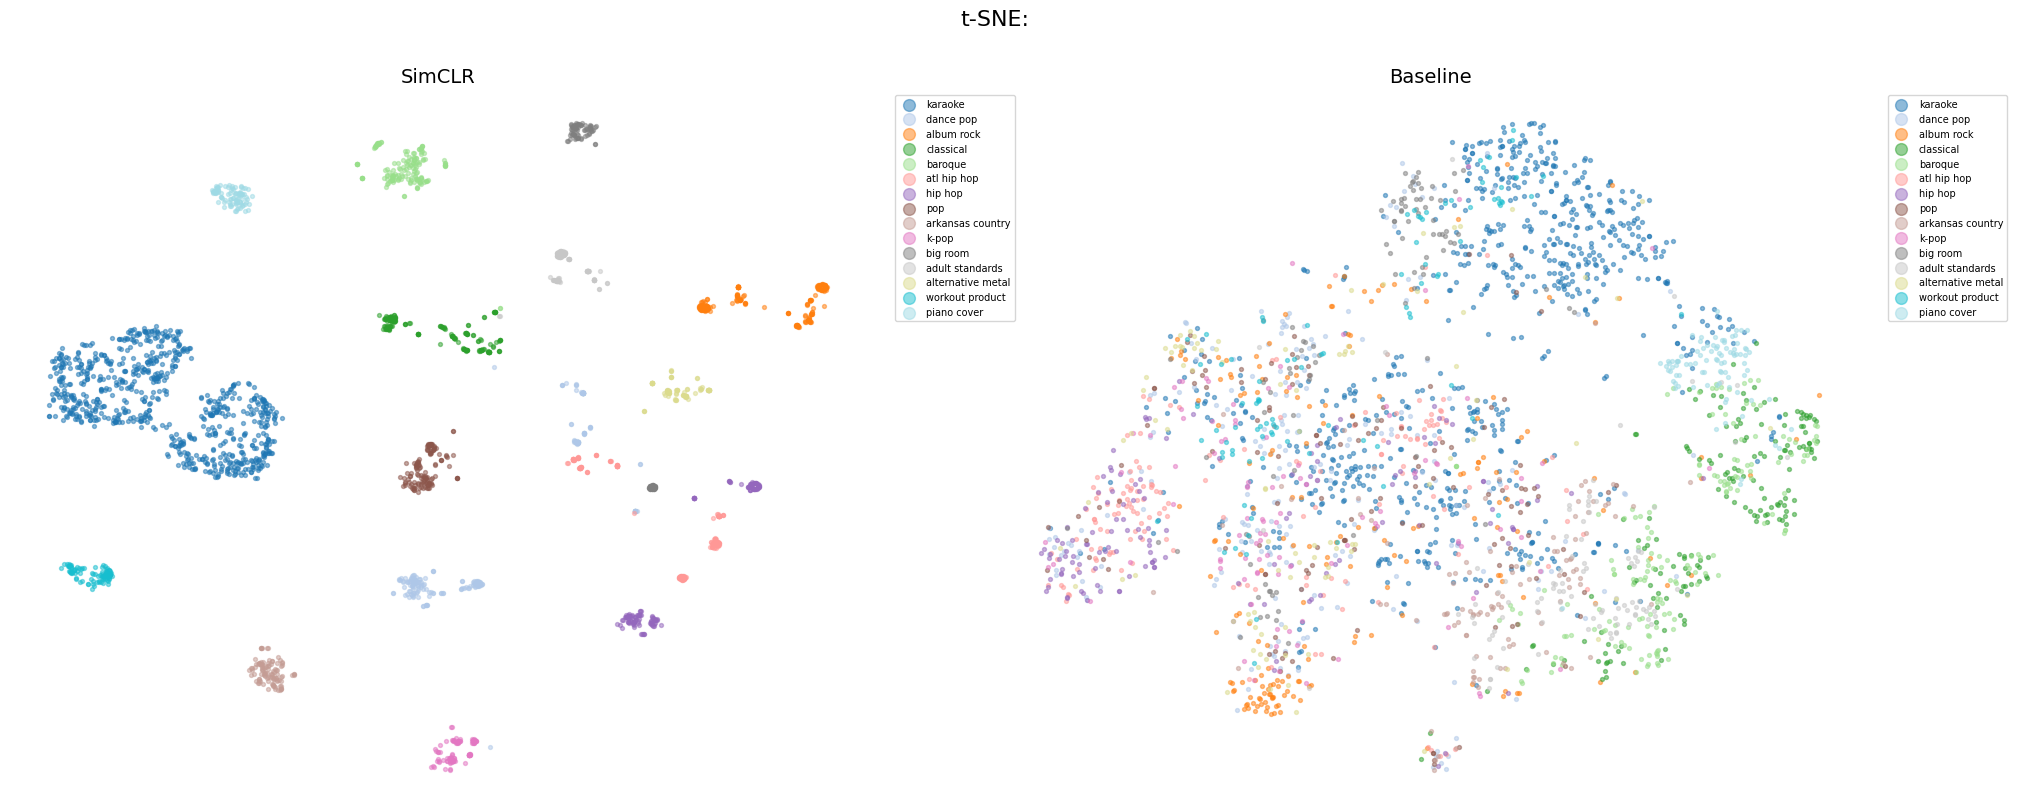

In [12]:
# Top 15 genres
top_genres = pd.Series(genre_labels).value_counts().nlargest(15).index.tolist()
mask = np.isin(genre_labels, top_genres)

emb_plot    = embeddings[mask]
labels_plot = genre_labels[mask]

print(f"Точок для t-SNE: {len(emb_plot):,}")
print("Запускаємо t-SNE...")

tsne = TSNE(n_components=2, perplexity=50, n_iter=1000,
            random_state=42, verbose=1)
emb_2d = tsne.fit_transform(emb_plot)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(top_genres)))
genre_color = {g: colors[i] for i, g in enumerate(top_genres)}

for ax, (title, data_2d) in zip(axes, [
    ("SimCLR", emb_2d),
    ("Baseline",
     TSNE(n_components=2, perplexity=50, n_iter=1000, random_state=42)
     .fit_transform(X_num[idx][mask]))
]):
    for genre in top_genres:
        m = labels_plot == genre
        ax.scatter(data_2d[m, 0], data_2d[m, 1],
                   c=[genre_color[genre]], label=genre,
                   alpha=0.5, s=8)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=7, markerscale=3,
              loc='upper right', bbox_to_anchor=(1.18, 1))
    ax.axis('off')

plt.suptitle("t-SNE:", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("tsne_genres.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Genre map - cluster centroids

Genres on the map: 195
Running t-SNE for centroids...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


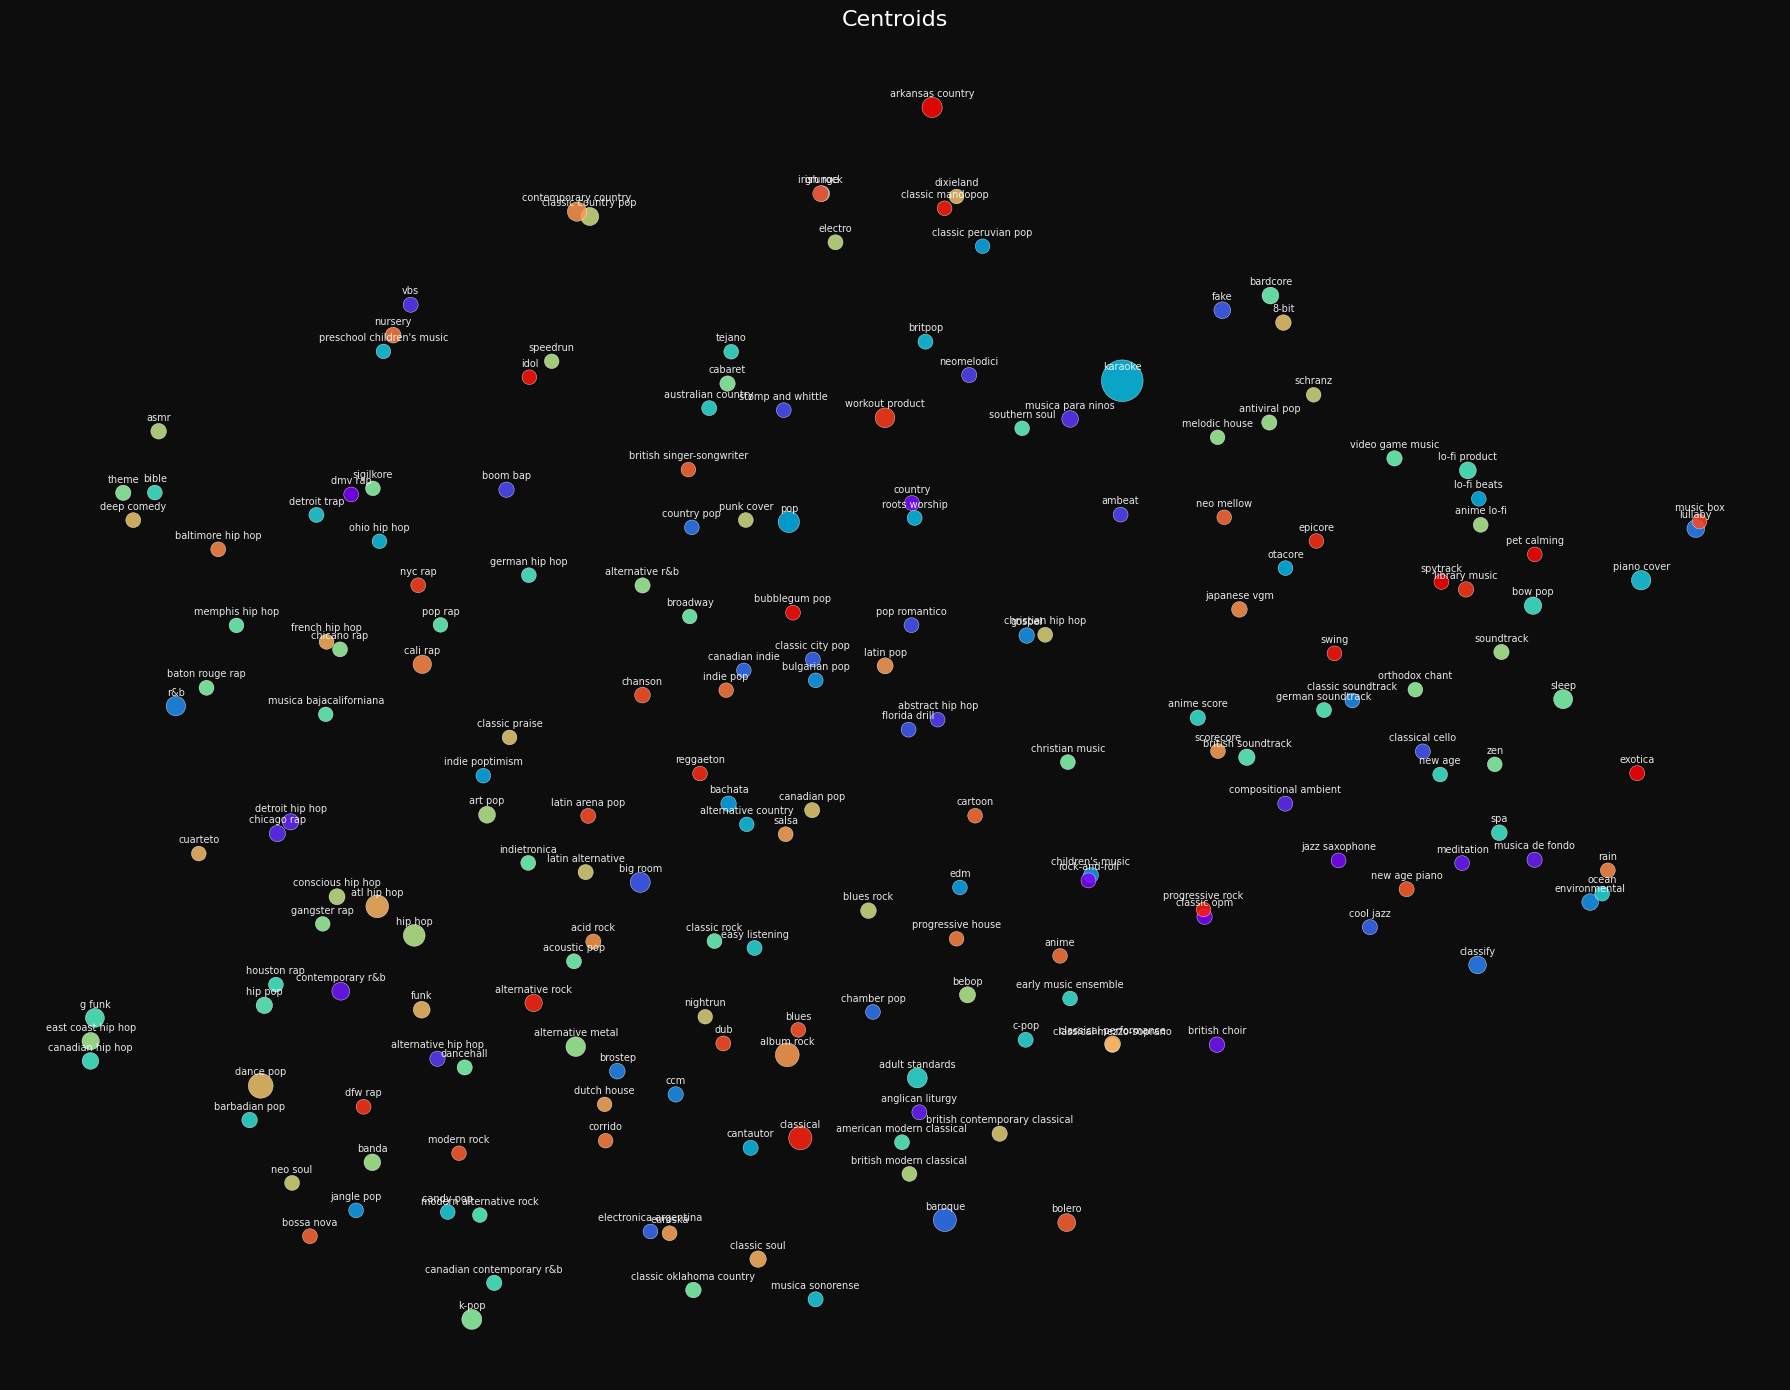

In [15]:
all_genres = np.unique(genre_labels)

centroids     = {}
centroid_labels = []
centroid_sizes  = []

for g in all_genres:
    m = genre_labels == g
    # ignore unpopular geners
    if m.sum() < 10:
        continue
    centroids[g] = embeddings[m].mean(axis=0)
    centroid_labels.append(g)
    centroid_sizes.append(m.sum())

centroid_matrix = np.array([centroids[g] for g in centroid_labels])
centroid_sizes  = np.array(centroid_sizes)

print(f"Genres on the map: {len(centroid_labels)}")
print("Running t-SNE for centroids...")

tsne_c = TSNE(n_components=2, perplexity=min(30, len(centroid_labels)//2),
              n_iter=2000, random_state=42)
centroids_2d = tsne_c.fit_transform(centroid_matrix)

# Map
fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#0d0d0d')

# Normalization
sizes = 100 + (centroid_sizes / centroid_sizes.max()) * 800

# Set color
cmap = plt.cm.rainbow
colors_c = cmap(np.linspace(0, 1, len(centroid_labels)))
np.random.seed(42)
np.random.shuffle(colors_c)

scatter = ax.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    s=sizes, c=colors_c, alpha=0.85, edgecolors='white', linewidths=0.3
)

for i in range(len(centroid_labels)):
    ax.annotate(
        centroid_labels[i],
        (centroids_2d[i, 0], centroids_2d[i, 1]),
        fontsize=7, color='white', alpha=0.9,
        ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points'
    )

ax.set_title("Centroids",
             fontsize=16, color='white', pad=15)
ax.axis('off')


plt.tight_layout()
plt.savefig("genre_map.png", dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')

## 8. Summary

In [14]:
print(f"Silhouette (baseline):  {sil_baseline:.4f}")
print(f"Silhouette (SimCLR):    {sil_simclr:.4f}")
print()
print("KNN Genre Precision:")
for k in Ks:
    neighbors = indices_simclr[:, 1:k+1]
    prec = np.mean([
        np.mean(genre_labels[neighbors[i]] == genre_labels[i])
        for i in range(len(idx))
    ])
    print(f"  Precision@{k:<3}: {prec:.4f}")

Silhouette (baseline):  -0.7224
Silhouette (SimCLR):    0.3431

KNN Genre Precision:
  Precision@5  : 0.7709
  Precision@20 : 0.5769
  Precision@50 : 0.4371
  Precision@100: 0.3361
